In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Standard imports
import numpy as np
import xarray as xr
import tqdm as tqdm
import matplotlib.pyplot as plt

In [3]:
# Import OpenSense modules as submodules
import sys
import os

sys.path.append(os.path.abspath("./pycomlink/"))
sys.path.append(os.path.abspath("./poligrain/src/"))
sys.path.append(os.path.abspath("./mergeplg/src/"))

import pycomlink as pycml 
import poligrain as plg
import mergeplg 

/home/erlend/git/radar_adjustment_intercomparison/pycomlink/pycomlink/io/examples.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [4]:
from sklearn.model_selection import KFold

In [5]:
os.makedirs('data/adjusted_fields', exist_ok=True)
months = ['2022-06', '2022-07', '2022-08']

In [6]:
# OpenRainER
ds_rad = xr.open_dataset("data/covi_2024_OpenRainER/openrainer_radar.nc")         
ds_cmls = xr.open_dataset("data/processed_cml_OpenRainER.nc").R_acc   
ds_gauges = xr.open_dataset('data/covi_2024_OpenRainER/AWS_rainfall.nc')        


In [7]:
folds = 30 #
n_sim = 1
max_distance = 500000
max_distance_checks = np.arange(10000, max_distance, 5000)
seed = 1


100%|█████████████████████████████████████████████| 1/1 [00:00<00:00,  2.14it/s]


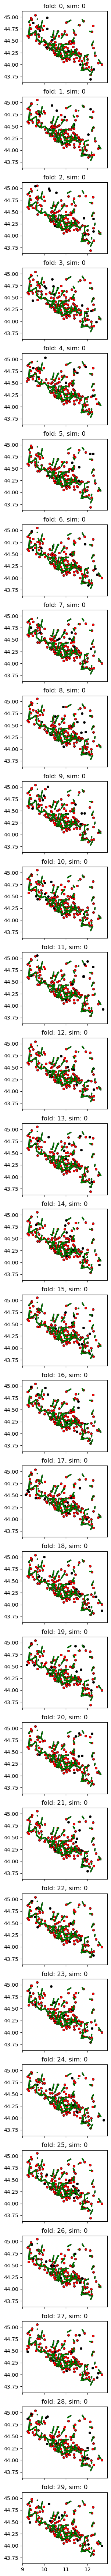

In [8]:
# 4 fold crossvalidation, illustration with map
fig, ax = plt.subplots(folds, n_sim, figsize=(n_sim*3, folds*3), sharex=True, sharey = True)
if n_sim == 1:
    ax = ax[:, np.newaxis]  # Add an extra dimension to make it a column
elif folds == 1:
    ax = ax[np.newaxis, :]  # Add an extra dimension to make it a row


kf = KFold(n_splits=folds, random_state=seed, shuffle=True)
rng = np.random.default_rng(seed=seed)

for i, (train_index, test_index) in enumerate(kf.split(np.arange(ds_gauges.id.size))):
    ds_gauges_train = ds_gauges.isel(id = train_index)
    ds_gauges_test = ds_gauges.isel(id = test_index)

    # Get train gauges close to CMLs
    gauges_near_cmls = plg.spatial.get_closest_points_to_line(ds_cmls, ds_gauges_train, max_distance=max_distance, n_closest=ds_gauges.id.size)

    # Sample n_sim times (bootstrap)
    for j in tqdm.tqdm(range(n_sim)):
        # Sample gauges close to CMLs
        gauges_list = []
        for cml_id in rng.permutation(gauges_near_cmls.cml_id.data): # For all cml_id in random order
    
            # Select cml
            gauges_candidates = gauges_near_cmls.sel(cml_id = cml_id)
            
            # Set gauges already used to None, these are ignored later
            gauges_not_in_list = ~np.isin(gauges_candidates.neighbor_id.data, gauges_list)
            gauges_candidates['neighbor_id'] = gauges_candidates.neighbor_id.where(gauges_not_in_list, None)

            # Prefer raingauges close to CML, but if no present expand search
            gauges_in_range = False
            counter = 0
            while gauges_in_range is False:
                max_distance_try = max_distance_checks[counter]
                gauges_candidates_try = gauges_candidates.where(gauges_candidates.distance < max_distance_try, drop=True)

                # Select gauges, dropping those set to None (outside range or already selected)
                gauges_candidates_try = gauges_candidates_try.neighbor_id.dropna(dim="n_closest")
                
                if gauges_candidates_try.n_closest.size > 0:
                    gauges_in_range = True
                    gauges_candidates = gauges_candidates_try

                else: 
                    counter+=1

            # Select randomly 1 gauge and store name
            indice = rng.integers(0, gauges_candidates.size)
            gauges_list.append(str(gauges_candidates.isel(n_closest = indice).data))

        

        # Plot train gauges
        plg.plot_map.plot_plg(
            da_gauges=ds_gauges_train.sel(id = gauges_list),
            da_cmls=ds_cmls.to_dataset(),
            use_lon_lat=True,
            ax=ax[i, j],
            point_color="r",
        );        

        # Plot test gauges
        plg.plot_map.plot_plg(
            da_gauges=ds_gauges_test,
            use_lon_lat=True,
            ax=ax[i, j],
            point_color="k",
        );        

        # Plot CMLs
        plg.plot_map.plot_plg(
            da_cmls=ds_cmls.to_dataset(),
            use_lon_lat=True,
            ax=ax[i, j],
            kwargs_cmls_plot={
                "line_color": "g",
            },
        );        
        ax[i, j].set_title('fold: ' + str(i) + ', sim: ' + str(j))

In [9]:
# 4 fold crossvalidation, additive IDW adjustment for gauges and CMLs
seed = 1
kf = KFold(n_splits=folds, random_state=seed, shuffle=True)
rng = np.random.default_rng(seed=seed)

for i, (train_index, test_index) in enumerate(kf.split(np.arange(ds_gauges.id.size))):
    ds_gauges_train = ds_gauges.isel(id = train_index)
    ds_gauges_test = ds_gauges.isel(id = test_index)

    # Get train gauges close to CMLs
    gauges_near_cmls = plg.spatial.get_closest_points_to_line(ds_cmls, ds_gauges_train, max_distance=max_distance, n_closest=ds_gauges.id.size)

    # Sample n_sim times (bootstrap)
    for j in tqdm.tqdm(range(n_sim)):
        # Sample gauges close to CMLs
        gauges_list = []
        for cml_id in rng.permutation(gauges_near_cmls.cml_id.data): # For all cml_id in random order
    
            # Select cml
            gauges_candidates = gauges_near_cmls.sel(cml_id = cml_id)
            
            # Set gauges already used to None, these are ignored later
            gauges_not_in_list = ~np.isin(gauges_candidates.neighbor_id.data, gauges_list)
            gauges_candidates['neighbor_id'] = gauges_candidates.neighbor_id.where(gauges_not_in_list, None)

            # Prefer raingauges close to CML, but if no present expand search
            gauges_in_range = False
            counter = 0
            while gauges_in_range is False:
                max_distance_try = max_distance_checks[counter]
                gauges_candidates_try = gauges_candidates.where(gauges_candidates.distance < max_distance_try, drop=True)

                # Select gauges, dropping those set to None (outside range or already selected)
                gauges_candidates_try = gauges_candidates_try.neighbor_id.dropna(dim="n_closest")
                
                if gauges_candidates_try.n_closest.size > 0:
                    gauges_in_range = True
                    gauges_candidates = gauges_candidates_try

                else: 
                    counter+=1

            # Select randomly 1 gauge and store name
            indice = rng.integers(0, gauges_candidates.size)
            gauges_list.append(str(gauges_candidates.isel(n_closest = indice).data))

        
        # additive IDW, gauges
        nnear = 12 
        rainfall = []
        
        for month in months:
            msel_ds_rad = ds_rad.sel(time = month) 
            msel_ds_gauges = ds_gauges_train.sel(id = gauges_list, time = month)
            
            # IDW merging initialization 
            merger = mergeplg.merge.MergeDifferenceIDW(
                ds_rad=msel_ds_rad.rainfall_amount,
                ds_gauges=msel_ds_gauges,
                method="additive",
                nnear=nnear,
                range_checks={'diff_check':10},
            )
            # merging application (loop on timesteps)
            for time in msel_ds_rad.time.data:
                rainfall.append(
                    merger(
                        da_rad=msel_ds_rad.sel(time=time).rainfall_amount,
                        da_gauges=msel_ds_gauges.sel(time=time).rainfall_amount,
                    )
                )
        # saving the field + removing NaNs 
        data = xr.Dataset({"rainfall_add_IDW": xr.concat(rainfall, dim="time") })
        data['rainfall_add_IDW']=xr.where(
            np.isnan(data['rainfall_add_IDW']), 0, data['rainfall_add_IDW']
            )
        data.to_netcdf('data/adjusted_fields/OpenRainER_add_IDW_gauges_4fold_'+str(i)+'-'+str(j) + '.nc')   
        del data, merger



100%|████████████████████████████████████████████| 1/1 [03:23<00:00, 203.19s/it]


In [8]:
# Rename radar data
ds_rad = ds_rad.rename({'rainfall_amount':'rainfall_radar'})  

In [9]:
# Load additive IDW using CMLs
ds_rad['rainfall_add_IDW']=xr.open_dataset('data/adjusted_fields/OpenRainER_rainfall_add_IDW.nc').rainfall_add_IDW

# Load results from k-fold gauges
for i in range(folds):
    # Sample n_sim times (bootstrap)
    for j in range(n_sim):
        filename = 'data/adjusted_fields/OpenRainER_add_IDW_gauges_4fold_'+str(i)+'-'+str(j) + '.nc'
        variable_name = 'gauges_fold'+str(i)+'_sim' + str(j)
        ds_rad[variable_name] = xr.open_dataset(filename).rainfall_add_IDW

In [10]:
import matplotlib.patches as mpatches
import pandas as pd

In [11]:
# Metrics, seed is the same so the selection can be repeated
threshold = 0.2

# Resets seed
kf = KFold(n_splits=folds, random_state=seed, shuffle=True)
rng = np.random.default_rng(seed=seed)

metrics = []

# For each fold, do metrics
for i, (train_index, test_index) in enumerate(kf.split(np.arange(ds_gauges.id.size))):
    ds_gauges_test = ds_gauges.isel(id = test_index)

    # Use fields adjusted to the train data for this fold
    fields = ['gauges_fold' + str(i) + '_sim' + str(j) for j in range(n_sim)]
    fields.append('rainfall_radar')
    fields.append('rainfall_add_IDW')
    
    # Sample fields at rain gauges
    get_grid_at_points = plg.spatial.GridAtPoints(
        da_gridded_data=ds_rad.isel(time = 0), 
        da_point_data=ds_gauges_test.isel(time = 0),
        nnear=1,
        stat="best" 
    )
    
    for field in fields:
        ds_gauges_test[field] = get_grid_at_points(
            da_gridded_data=ds_rad[field],
            da_point_data=ds_gauges_test.rainfall_amount,  
        )

    mm = []
    for ii in range(len(fields)):
        metric = pd.DataFrame([plg.validation.calculate_rainfall_metrics(
            reference=ds_gauges_test.rainfall_amount.values.flatten(),
            estimate=ds_gauges_test[fields[ii]].values.flatten(),
            ref_thresh=threshold,
            est_thresh=threshold)])

        mm.append([
            metric.root_mean_square_error,
            metric.mean_absolute_error,
            metric.percent_bias,
            metric.pearson_correlation_coefficient
        ])
    metrics.append(mm)

In [12]:
metrics = np.array(metrics)

Text(0.5, 1.0, 'PCC')

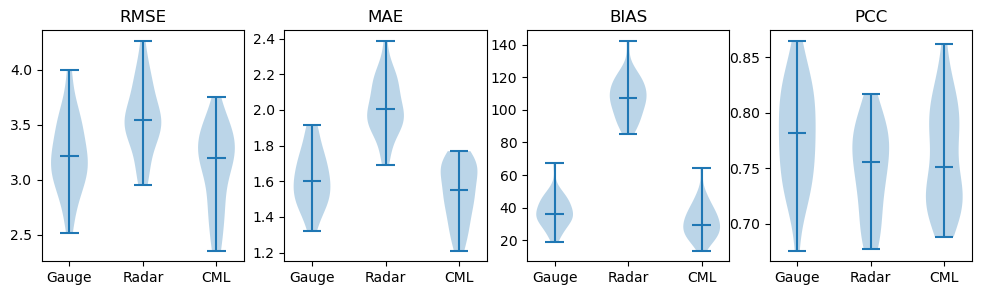

In [13]:
fig, ax = plt.subplots(1, 4, figsize=(12, 3))

for i in range(4):
    all_data = metrics[:, :, i, 0]
    ax[i].violinplot(all_data, showmeans=False, showmedians=True)
    ax[i].set_xticks([y + 1 for y in range(all_data.shape[1])], 
                     labels=['Gauge', 'Radar', 'CML'])
    
    
ax[0].set_title('RMSE')
ax[1].set_title('MAE')
ax[2].set_title('BIAS')
ax[3].set_title('PCC')


In [15]:
ds_cmls

<xarray.DataArray 'R_acc' (cml_id: 127, time: 2207)> Size: 2MB
[280289 values with dtype=float64]
Coordinates: (12/15)
  * cml_id       (cml_id) <U4 2kB '263' '63' '175' '145' ... '1134' '136' '556'
  * time         (time) datetime64[ns] 18kB 2022-06-01T01:00:00 ... 2022-08-3...
    length       (cml_id) float64 1kB ...
    site_0_lat   (cml_id) float64 1kB ...
    site_0_lon   (cml_id) float64 1kB ...
    site_0_elev  (cml_id) float64 1kB ...
    ...           ...
    site_0_x     (cml_id) float64 1kB ...
    site_0_y     (cml_id) float64 1kB ...
    site_1_x     (cml_id) float64 1kB ...
    site_1_y     (cml_id) float64 1kB ...
    x            (cml_id) float64 1kB ...
    y            (cml_id) float64 1kB ...